In [1]:
import os

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/ImmunoPath"
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/data", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/models", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/results/phase0", exist_ok=True)



from huggingface_hub import login
from google.colab import userdata
try:
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
    print("Logged in to HuggingFace via Colab secret")
except Exception:
    print("Set HF_TOKEN in Colab Secrets (key icon in sidebar)")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Logged in to HuggingFace via Colab secret


## Installing dependancies

In [2]:
import subprocess
subprocess.run([
    "pip", "install", "-q", "--upgrade",
    "transformers>=4.50.0",   # Gemma 3 minimum
    "accelerate>=0.34.0",
    "bitsandbytes>=0.44.0",
    "pillow>=10.0.0",
], check=True)


CompletedProcess(args=['pip', 'install', '-q', '--upgrade', 'transformers>=4.50.0', 'accelerate>=0.34.0', 'bitsandbytes>=0.44.0', 'pillow>=10.0.0'], returncode=0)

In [3]:

import transformers
print(f"Dependencies installed (transformers=={transformers.__version__})")
import torch
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {gpu_name} ({gpu_mem:.1f} GB)")
    print(f"   bfloat16 support: {torch.cuda.is_bf16_supported()}")
else:
    print("No GPU! Runtime → Change runtime type → GPU (T4 minimum, A100 ideal)")

Dependencies installed (transformers==5.1.0)
GPU: NVIDIA A100-SXM4-40GB (42.5 GB)
   bfloat16 support: True


## Create Synthetic H&E Test Images

Found existing installation: pillow 12.1.0
Uninstalling pillow-12.1.0:
  Successfully uninstalled pillow-12.1.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 84.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.1.0 which is incompatible.
Created 8 synthetic H&E patches (512×512)
Saved sample to: /content/drive/MyDrive/ImmunoPath/results/phase0/test_patch_0.jpg


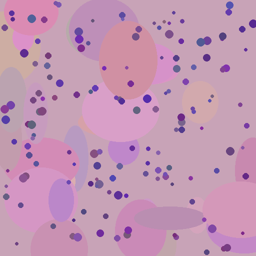

In [4]:
!pip uninstall -y Pillow
!pip install --no-cache-dir --upgrade Pillow

import numpy as np
from PIL import Image, ImageDraw
import random

def create_synthetic_he_patch(size=512, seed=None):
    """
    Create a synthetic H&E-like histopathology patch.
    Pink background (eosin) + purple dots (hematoxylin nuclei).
    This is NOT a real histopathology image — just for testing model I/O.
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    # Pink eosin background with slight variation
    bg_r = np.random.randint(200, 240)
    bg_g = np.random.randint(160, 200)
    bg_b = np.random.randint(180, 220)
    img = Image.new('RGB', (size, size), (bg_r, bg_g, bg_b))
    draw = ImageDraw.Draw(img)

    # Add tissue-like texture (lighter pink regions)
    for _ in range(30):
        x, y = random.randint(0, size), random.randint(0, size)
        rx, ry = random.randint(20, 80), random.randint(20, 80)
        color = (bg_r + random.randint(-20, 20),
                 bg_g + random.randint(-30, 10),
                 bg_b + random.randint(-20, 20))
        color = tuple(max(0, min(255, c)) for c in color)
        draw.ellipse([x-rx, y-ry, x+rx, y+ry], fill=color)

    # Purple nuclei (hematoxylin-stained)
    n_nuclei = random.randint(50, 300)
    for _ in range(n_nuclei):
        x, y = random.randint(5, size-5), random.randint(5, size-5)
        r = random.randint(3, 8)
        purple = (random.randint(80, 140),
                  random.randint(40, 100),
                  random.randint(120, 180))
        draw.ellipse([x-r, y-r, x+r, y+r], fill=purple)

    # Occasional lymphocyte clusters (darker, smaller, denser)
    if random.random() > 0.5:
        cx, cy = random.randint(50, size-50), random.randint(50, size-50)
        for _ in range(random.randint(20, 60)):
            x = cx + random.randint(-30, 30)
            y = cy + random.randint(-30, 30)
            r = random.randint(2, 4)
            dark_purple = (random.randint(50, 90),
                           random.randint(20, 60),
                           random.randint(80, 130))
            draw.ellipse([x-r, y-r, x+r, y+r], fill=dark_purple)

    return img

# Generate 8 test patches with different seeds (for reproducibility)
test_images = [create_synthetic_he_patch(512, seed=i) for i in range(8)]
print(f"Created {len(test_images)} synthetic H&E patches (512×512)")

# Save one for visual inspection
test_images[0].save(f"{PROJECT_DIR}/results/phase0/test_patch_0.jpg", quality=95)
print(f"Saved sample to: {PROJECT_DIR}/results/phase0/test_patch_0.jpg")

# Display the first patch
from IPython.display import display
display(test_images[0].resize((256, 256)))

## Loading MedGemma

In [5]:
from transformers import AutoProcessor, AutoModelForImageTextToText
import torch

MODEL_ID = "google/medgemma-1.5-4b-it"

print(f"Loading {MODEL_ID}...")
print(f"  dtype: torch.bfloat16")
print(f"  device_map: auto")
print()

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    offload_buffers=True,
)
model.eval()

# CUDA optimizations
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

# Print memory usage
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1e9
    reserved = torch.cuda.memory_reserved() / 1e9
    print(f"Model loaded successfully!")
    print(f"   VRAM allocated: {allocated:.2f} GB")
    print(f"   VRAM reserved:  {reserved:.2f} GB")

Loading google/medgemma-1.5-4b-it...
  dtype: torch.bfloat16
  device_map: auto



processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

The image processor of type `Gemma3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/115 [00:00<?, ?B/s]

Model loaded successfully!
   VRAM allocated: 8.60 GB
   VRAM reserved:  8.62 GB


/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)


## TEST 1 — Single Image Sanity Check

In [6]:
# Goal: Verify model loads, processes one image, generates text.

SINGLE_IMAGE_PROMPT = """Analyze this H&E-stained histopathology image from a lung adenocarcinoma tumor.

Describe what you observe in terms of:
1. Tissue architecture
2. Nuclear morphology
3. Any signs of immune infiltration

Keep your answer concise (3-5 sentences)."""

def run_single_image_test(image, prompt):
    """Test MedGemma with a single image input."""
    # Build chat message — image object MUST be included in the message
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": prompt},
            ],
        }
    ]

    # Process inputs — ONE-CALL pattern (tokenize + return_dict in apply_chat_template)
    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )
    inputs = {k: v.to(model.device, dtype=torch.bfloat16) if v.is_floating_point()
              else v.to(model.device) for k, v in inputs.items() if torch.is_tensor(v)}

    # Generate with inference_mode (more efficient than no_grad)
    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=512,
            do_sample=False,  # deterministic for testing
        )

    # Decode using post_process_image_text_to_text
    response = processor.post_process_image_text_to_text(output_ids, skip_special_tokens=True)
    # Strip the input prompt from decoded output (returns list)
    return response[0].split("model\n")[-1].strip() if response else ""

print("X" * 15)
print("TEST 1: Single Image Sanity Check")
print("X" * 15)

try:
    response = run_single_image_test(test_images[0], SINGLE_IMAGE_PROMPT)
    print(f"\nPASS — Model generated response ({len(response)} chars)")
    print(f"\nResponse:\n{response[:500]}")
    test1_pass = True
except Exception as e:
    print(f"\nFAIL — {type(e).__name__}: {e}")
    test1_pass = False

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


XXXXXXXXXXXXXXX
TEST 1: Single Image Sanity Check
XXXXXXXXXXXXXXX

PASS — Model generated response (380 chars)

Response:
The image shows a histopathology slide of a lung adenocarcinoma tumor. The tissue architecture appears disorganized, with a mix of cellular and acellular areas. The nuclei of the tumor cells are enlarged and pleomorphic, with irregular shapes and chromatin patterns. There is a lack of a well-defined cellular pattern. There is no obvious immune infiltration visible in the image.


## TEST 2 — Multi-Image Capacity Test

In [7]:
# Goal: Determine how many images MedGemma can handle in one prompt.
# This is the key architecture decision: multi-image vs collage.

MULTI_IMAGE_PROMPT = """Analyze these H&E-stained histopathology patches from a lung adenocarcinoma tumor.

These patches are from different regions of the same whole-slide image.
Provide a brief overall assessment of the tumor microenvironment.
Keep your answer concise."""

def run_multi_image_test(images, prompt):
    """Test MedGemma with multiple image inputs."""
    # Build content list: one {"type": "image", "image": img} per image, then text
    content = [{"type": "image", "image": img} for img in images]
    content.append({"type": "text", "text": prompt})

    messages = [{"role": "user", "content": content}]

    # ONE-CALL pattern
    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )
    inputs = {k: v.to(model.device, dtype=torch.bfloat16) if v.is_floating_point()
              else v.to(model.device) for k, v in inputs.items() if torch.is_tensor(v)}

    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=512,
            do_sample=False,
        )

    response = processor.post_process_image_text_to_text(output_ids, skip_special_tokens=True)
    return response[0].split("model\n")[-1].strip() if response else ""

print("X" * 15)
print("TEST 2: Multi-Image Capacity Test")
print("X" * 15)

image_counts = [1, 2, 4, 8]
multi_image_results = {}

for n in image_counts:
    print(f"\nTesting {n} image(s) ")
    try:
        imgs = test_images[:n]
        response = run_multi_image_test(imgs, MULTI_IMAGE_PROMPT)
        multi_image_results[n] = {
            "status": "PASS",
            "response_len": len(response),
            "response_preview": response[:200],
        }
        print(f"PASS — {len(response)} chars")

        # Clear CUDA cache between tests
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    except torch.cuda.OutOfMemoryError:
        multi_image_results[n] = {"status": "OOM"}
        print(f"OOM — Out of GPU memory")
        torch.cuda.empty_cache()
        break  # No point testing more images

    except Exception as e:
        multi_image_results[n] = {"status": "FAIL", "error": str(e)}
        print(f"FAIL — {type(e).__name__}: {str(e)[:100]}")

# Determine max working image count
max_images = 0
for n in image_counts:
    if n in multi_image_results and multi_image_results[n]["status"] == "PASS":
        max_images = n

print(f"\n{'X' * 15}")
print(f"RESULT: Max working images = {max_images}")
print(f"{'X' * 15}")

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


XXXXXXXXXXXXXXX
TEST 2: Multi-Image Capacity Test
XXXXXXXXXXXXXXX

Testing 1 image(s) 


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


PASS — 302 chars

Testing 2 image(s) 


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


PASS — 272 chars

Testing 4 image(s) 


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


PASS — 272 chars

Testing 8 image(s) 
PASS — 342 chars

XXXXXXXXXXXXXXX
RESULT: Max working images = 8
XXXXXXXXXXXXXXX


## TEST 3 — JSON Output Reliability

In [8]:
# Goal: Test if MedGemma can output valid JSON with our exact schema.
# Run 10 trials and measure parse rate.

import json

JSON_PROMPT = """Analyze these H&E-stained histopathology images from a lung adenocarcinoma tumor.

Extract the following H&E-inferred immune signals as a research output (not diagnostic):
1. CD274 (PD-L1) RNA proxy level (high/low)
2. MSI status (MSI-H or MSS) + probability
3. TIL fraction (0.0-1.0) + bucket (low/moderate/high)
4. TME subtype (IE / IE/F / F / D)
5. Immune phenotype (inflamed/excluded/desert)
6. CD8+ T-cell infiltration (low/moderate/high)
7. Overall immune score (0.0-1.0)

Provide your analysis as a JSON object only. No other text."""

# Use the max working image count from Test 2
n_images_for_json = min(max_images, 4) if max_images > 0 else 1
print(f"Using {n_images_for_json} image(s) for JSON test\n")

def extract_json_from_response(response_text):
    """Try to parse JSON from model response with fallback strategies."""
    text = response_text.strip()

    # Strategy 1: Direct parse
    try:
        return json.loads(text), "direct"
    except json.JSONDecodeError:
        pass

    # Strategy 2: Extract from markdown code block
    if "```json" in text:
        start = text.index("```json") + 7
        end = text.index("```", start)
        try:
            return json.loads(text[start:end].strip()), "markdown_block"
        except (json.JSONDecodeError, ValueError):
            pass

    if "```" in text:
        start = text.index("```") + 3
        end = text.index("```", start) if "```" in text[start:] else len(text)
        try:
            return json.loads(text[start:end].strip()), "code_block"
        except (json.JSONDecodeError, ValueError):
            pass

    # Strategy 3: Find first { ... } block
    brace_start = text.find("{")
    brace_end = text.rfind("}") + 1
    if brace_start >= 0 and brace_end > brace_start:
        try:
            return json.loads(text[brace_start:brace_end]), "brace_extract"
        except json.JSONDecodeError:
            pass

    return None, "failed"

print("X" * 15)
print("TEST 3: JSON Output Reliability (10 trials)")
print("X" * 15)

N_TRIALS = 10
json_results = []

for trial in range(N_TRIALS):
    print(f"\n--- Trial {trial + 1}/{N_TRIALS} ---")
    try:
        # Use different image subsets for variety
        start_idx = trial % (len(test_images) - n_images_for_json + 1)
        imgs = test_images[start_idx : start_idx + n_images_for_json]

        # Use do_sample=True with temperature for variety across trials
        content = [{"type": "image", "image": img} for img in imgs]
        content.append({"type": "text", "text": JSON_PROMPT})
        messages = [{"role": "user", "content": content}]

        # ONE-CALL pattern
        inputs = processor.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=True,
            return_dict=True,
            return_tensors="pt",
        )
        inputs = {k: v.to(model.device, dtype=torch.bfloat16) if v.is_floating_point()
                  else v.to(model.device) for k, v in inputs.items() if torch.is_tensor(v)}

        with torch.inference_mode():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=1024,
                do_sample=(trial > 0),  # deterministic first trial, random after
                temperature=0.7 if trial > 0 else 1.0,
            )

        response_list = processor.post_process_image_text_to_text(output_ids, skip_special_tokens=True)
        response = response_list[0].split("model\n")[-1].strip() if response_list else ""

        parsed, method = extract_json_from_response(response)

        if parsed is not None:
            print(f"JSON parsed ({method})")
            print(f"     Keys: {list(parsed.keys())[:5]}...")
            json_results.append({"trial": trial, "success": True, "method": method,
                                 "data": parsed, "raw": response})
        else:
            print(f"JSON parse failed")
            print(f"     Raw (first 200 chars): {response[:200]}")
            json_results.append({"trial": trial, "success": False, "raw": response})

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    except Exception as e:
        print(f"Error: {type(e).__name__}: {str(e)[:100]}")
        json_results.append({"trial": trial, "success": False, "error": str(e)})

# Calculate parse rate
successes = sum(1 for r in json_results if r["success"])
parse_rate = (successes / N_TRIALS) * 100

print(f"\n{'X' * 15}")
print(f"JSON PARSE RATE: {successes}/{N_TRIALS} = {parse_rate:.0f}%")
print(f"{'X' * 15}")

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Using 4 image(s) for JSON test

XXXXXXXXXXXXXXX
TEST 3: JSON Output Reliability (10 trials)
XXXXXXXXXXXXXXX

--- Trial 1/10 ---


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


JSON parsed (markdown_block)
     Keys: ['CD274_proxy_level', 'msi_status', 'til_fraction', 'tme_subtype', 'immune_phenotype']...

--- Trial 2/10 ---


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


...

JSON parsed (markdown_block)
     Keys: ['cd274_proxy_level', 'msi_status', 'til_fraction', 'tme_subtype', 'immune_phenotype']...

--- Trial 8/10 ---


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


JSON parsed (markdown_block)
     Keys: ['cd274_proxy_level', 'msi_status', 'til_fraction', 'tme_subtype', 'immune_phenotype']...

--- Trial 9/10 ---


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


JSON parsed (markdown_block)
     Keys: ['cd274_proxy', 'msi_status', 'til_fraction', 'tme_subtype', 'immune_phenotype']...

--- Trial 10/10 ---
JSON parsed (markdown_block)
     Keys: ['CD274_proxy_level', 'msi_status', 'til_fraction', 'tme_subtype', 'immune_phenotype']...

XXXXXXXXXXXXXXX
JSON PARSE RATE: 10/10 = 100%
XXXXXXXXXXXXXXX


## Architecture Decision + Results Summary

In [9]:
# Apply the decision matrix and save all results.

import json
from datetime import datetime


if max_images >= 4 and parse_rate >= 80:
    architecture = "multi_image"
    arch_desc = "Multi-image input (4-8 patches per call)"
elif max_images >= 4 and parse_rate < 80:
    architecture = "multi_image_with_repair"
    arch_desc = "Multi-image + JSON post-processing repair"
elif max_images >= 1:
    architecture = "collage"
    arch_desc = "Single tile collage (3×3 mosaic of patches)"
else:
    architecture = "debug_required"
    arch_desc = "Setup needs debugging — model failed to load/generate"

print("X" * 15)
print("PHASE 0 RESULTS SUMMARY")
print("X" * 15)
print()
print(f"Test 1 (Single Image):   {'PASS' if test1_pass else 'FAIL'}")
print(f"Test 2 (Multi-Image):    Max images = {max_images}")
print(f"Test 3 (JSON Parse):     {parse_rate:.0f}% ({successes}/{N_TRIALS})")
print()
print(f"Architecture Decision: {arch_desc}")
print(f"    (Code: {architecture})")
print()

#saving to drive
results = {
    "phase": 0,
    "timestamp": datetime.now().isoformat(),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none",
    "model_id": "google/medgemma-1.5-4b-it",
    "test1_single_image": test1_pass,
    "test2_max_images": max_images,
    "test2_details": {str(k): v for k, v in multi_image_results.items()},
    "test3_json_parse_rate": parse_rate,
    "test3_successes": successes,
    "test3_total": N_TRIALS,
    "architecture_decision": architecture,
    "architecture_description": arch_desc,
}

results_path = f"{PROJECT_DIR}/results/phase0/phase0_results.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=2, default=str)

print(f"Results saved to: {results_path}")
print()



XXXXXXXXXXXXXXX
PHASE 0 RESULTS SUMMARY
XXXXXXXXXXXXXXX

Test 1 (Single Image):   PASS
Test 2 (Multi-Image):    Max images = 8
Test 3 (JSON Parse):     100% (10/10)

Architecture Decision: Multi-image input (4-8 patches per call)
    (Code: multi_image)

Results saved to: /content/drive/MyDrive/ImmunoPath/results/phase0/phase0_results.json

